Instalasi Library

In [1]:
!pip install network matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3138 sha256=b2f71cd6d8e28b1003671000d84348c690f0702ebb4cf05eee68de8f75dcb0c9
  Stored in directory: /root/.cache/pip/wheels/e7/5a/7a/7f15bea66afb5505b9d10cc7bd8964cb77f0ce736df5b104c8
Successfully built network


Algoritma Djikstra

In [3]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths (graph, start) :
    distances = {node: float('inf') for node in graph}
    distances [start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
      current_distance, current_node = heapq. heappop (queue)

      for neighbor, weight in graph[current_node].items () :
        distance = current_distance + weight
        if distance < distances [neighbor] :
          distances [neighbor] = distance
          previous [neighbor] = current_node
          heapq.heappush (queue, (distance, neighbor))

    return distances, previous

Fungsi untuk penggunaan Dijsktra (Rekonstruksi Jalur)

In [5]:
# Function
def get_path(previous, target):
  path =[]
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

Visualisasi dengan networkx dan matplotlib

In [8]:
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
      for neighbor, weight in graph[node].items():
         G.add_edge(node, neighbor, weight=weight)

  # Calculate position and edge labels once after graph is built
  pos = nx.spring_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8,6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
  font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len (path) > 1:
    path_edges = list (zip (path, path[1:]))
    nx.draw_networkx_edges (G, pos, edgelist=path_edges, edge_color='red',
    width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()


Penggunaan lengkap

Jarak dari A ke Z: 14 
Jalur: A -B -D -E -Z 


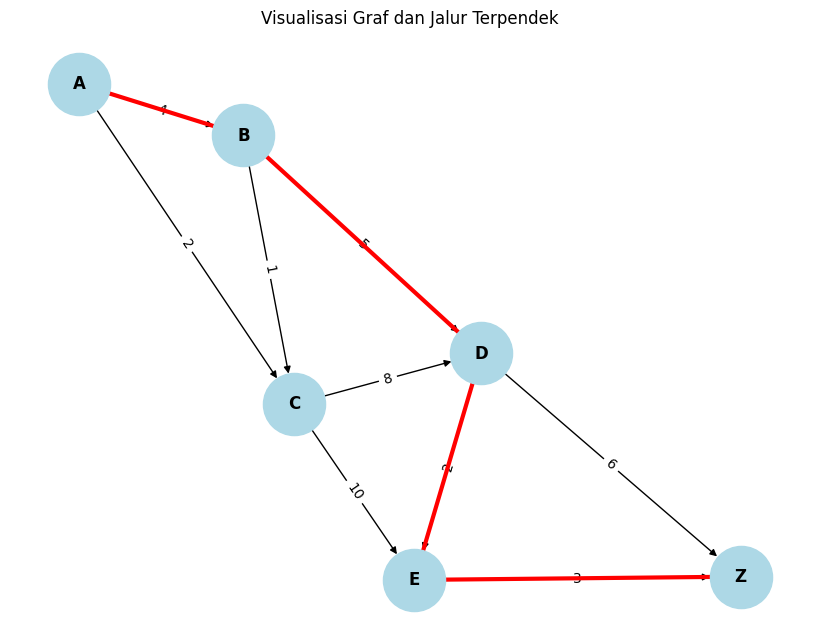

In [10]:
# Definisi graf
graph = {
'A': {'B': 4, 'C': 2},
'B': {'C': 1, 'D': 5},
'C': {'D': 8, 'E': 10},
'D': {'E': 2, 'Z': 6},
'E': {'Z': 3},
'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node}: {distances [end_node ] } ")
print(f"Jalur: {' -'.join (shortest_path) } ")

# Visualisasi
visualize_graph (graph, path=shortest_path)


Tugas 1

===== GRAF DENGAN SIKLUS =====
Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


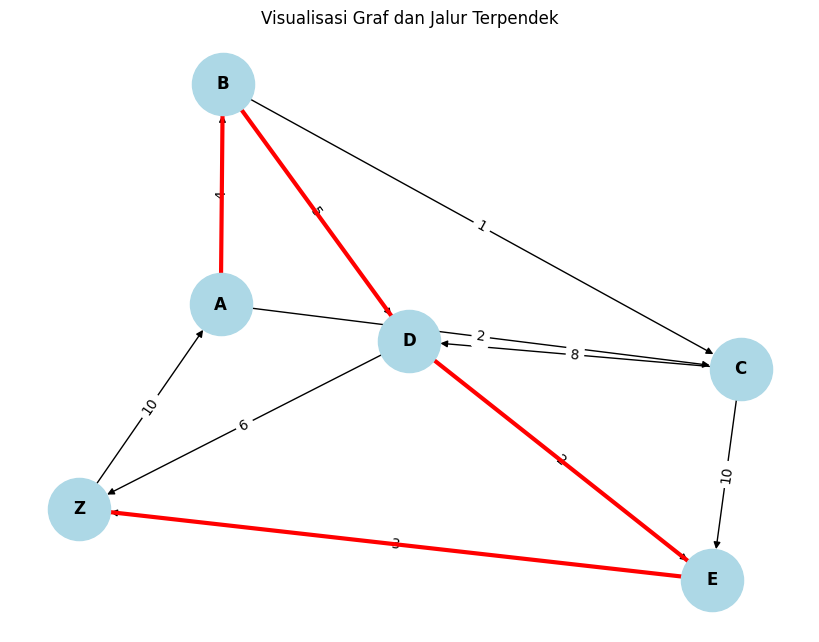

In [11]:
# Graf dengan siklus
graph_with_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {'A': 10}
}

distances2, previous2 = dijkstra_with_paths(graph_with_cycle, 'A')
shortest_path2 = get_path(previous2, 'Z')

print("===== GRAF DENGAN SIKLUS =====")
print(f"Jarak dari A ke Z: {distances2['Z']}")
print(f"Jalur: {' -> '.join(shortest_path2)}")

visualize_graph(graph_with_cycle, path=shortest_path2)

Tugas 2

===== GRAF DENGAN SIMPUL X =====
Jarak dari A ke Z: 7
Jalur: A -> C -> X -> Z


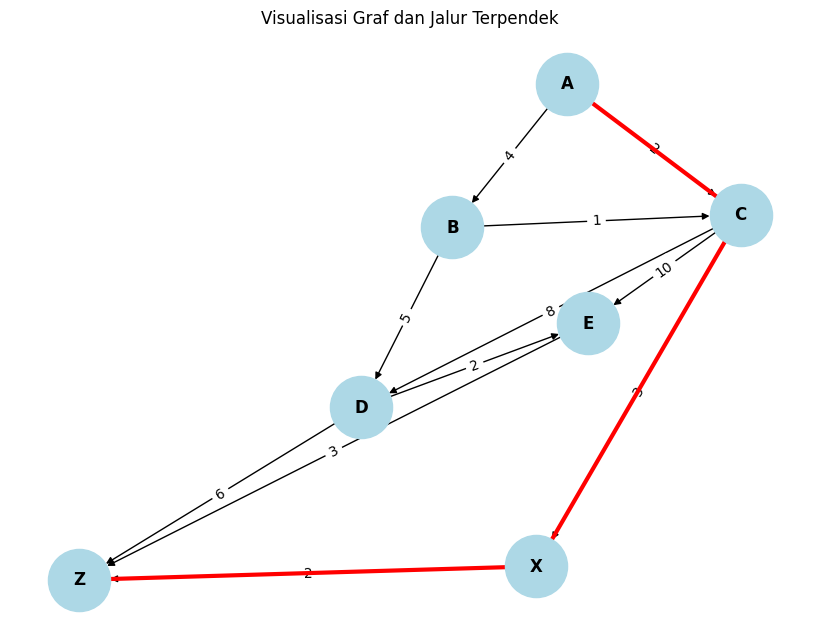

In [12]:
# Graf dengan simpul baru 'X'
graph_with_X = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'X': 3},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'X': {'Z': 2},
    'Z': {}
}

distances3, previous3 = dijkstra_with_paths(graph_with_X, 'A')
shortest_path3 = get_path(previous3, 'Z')

print("===== GRAF DENGAN SIMPUL X =====")
print(f"Jarak dari A ke Z: {distances3['Z']}")
print(f"Jalur: {' -> '.join(shortest_path3)}")

visualize_graph(graph_with_X, path=shortest_path3)

Tugas 3

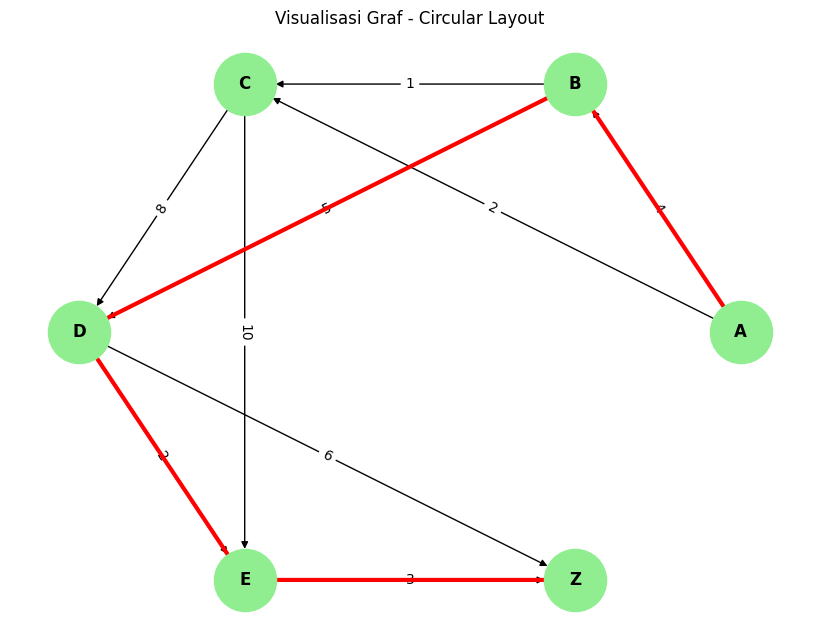

In [13]:
def visualize_graph_circular(graph, path=None):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Ganti layout menjadi circular
    pos = nx.circular_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightgreen',
            node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='red', width=3)

    plt.title("Visualisasi Graf - Circular Layout")
    plt.axis('off')
    plt.show()

# Panggil fungsi dengan layout circular
visualize_graph_circular(graph, path=shortest_path)